In [157]:
import os
import numpy as np
import pickle
import sklearn
import pandas as pd
import scipy
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Stress detection

Load the dataset

In the dataset we have measures and labels associated.
0 = not defined / transient, 1 = baseline, 2 = stress, 3 = amusement, 4 = meditation, 5/6/7 = should be ignored in this dataset

In [158]:
DATASET_PATH = "dataset/WESAD/"

We only keep what's interesting for us, ECG signal for each patient

In [159]:
patients_data = {}

for subject in os.listdir(DATASET_PATH):
    subject_path = os.path.join(DATASET_PATH, subject)

    if os.path.isdir(subject_path):
        file_path = os.path.join(subject_path, f"{subject}.pkl")

        if os.path.exists(file_path):
            with open(file_path, "rb") as f:
                data = pickle.load(f, encoding="latin1")

            ecg = data['signal']['chest']['ECG'].flatten()
            labels = data['label']

            df = pd.DataFrame({
                "ECG": ecg,
                "label": labels
            })

            patients_data[subject] = df
            
#Exemple
print(patients_data["S2"].head())

C:\Users\emnab\AppData\Local\Temp\ipykernel_59604\3887042567.py:11: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="latin1")


        ECG  label
0  0.021423      0
1  0.020325      0
2  0.016525      0
3  0.016708      0
4  0.011673      0


We see a lot of lable 0 (undefined)

In [160]:
df_s2 = patients_data["S2"]
proportions = df_s2["label"].value_counts(normalize=True)

print(proportions)

label
0    0.503537
1    0.188189
4    0.126336
2    0.101168
3    0.059549
6    0.010693
7    0.010528
Name: proportion, dtype: float64


More than 50% of our measures are label 0 and can't be used for patient 2, we'll delete them with label 5/6/7 as it's written in the readme of the dataset that they should be ignored.

In [161]:
labels_to_remove = [0, 5, 6, 7]

for subject in patients_data:
    df = patients_data[subject]
    
    # filtrage
    df_clean = df[~df["label"].isin(labels_to_remove)]
    
    # reset index (optionnel mais propre)
    df_clean = df_clean.reset_index(drop=True)
    
    patients_data[subject] = df_clean

df_s2 = patients_data["S2"]
proportions = df_s2["label"].value_counts(normalize=True)

print(proportions)

label
1    0.395985
4    0.265836
2    0.212877
3    0.125303
Name: proportion, dtype: float64


Let's visualize the data

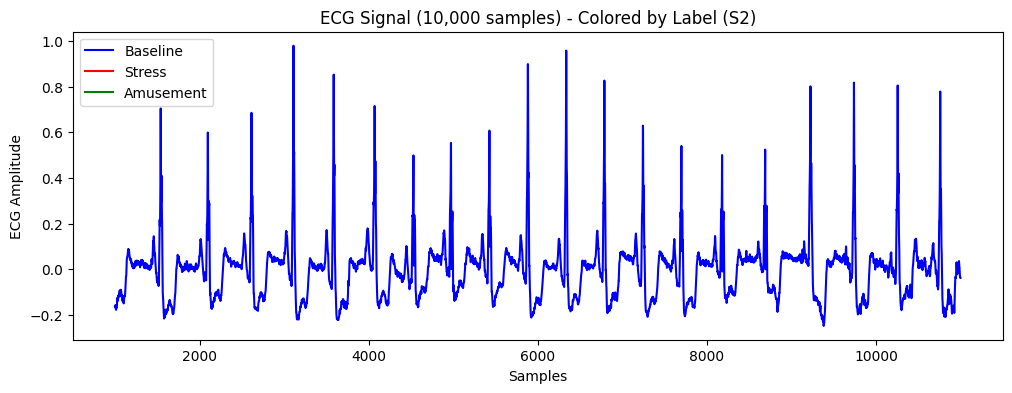

In [162]:
df_s2 = patients_data["S2"]

start = 1000
end = start + 10000

ecg = df_s2["ECG"].values[start:end]
labels = df_s2["label"].values[start:end]

colors = {1: "blue", 2: "red", 3: "green"}

plt.figure(figsize=(12, 4))

# tracer par segments de même label
i = 0
while i < len(ecg) - 1:
    j = i
    # trouver segment où label est constant
    while j < len(ecg) - 1 and labels[j] == labels[j + 1]:
        j += 1

    plt.plot(range(start + i, start + j + 1),
             ecg[i:j+1],
             color=colors.get(labels[i], "black"))

    i = j + 1

plt.title("ECG Signal (10,000 samples) - Colored by Label (S2)")
plt.xlabel("Samples")
plt.ylabel("ECG Amplitude")

legend_elements = [
    Line2D([0], [0], color='blue', label='Baseline'),
    Line2D([0], [0], color='red', label='Stress'),
    Line2D([0], [0], color='green', label='Amusement')
]

plt.legend(handles=legend_elements)

plt.show()

Feature engineering

Time-domain feature

RR intervals

In [163]:
sampling_rate = 700  # WESAD ECG sampling frequency in Hz (samplesper second)
patients_rr_intervals = {}

for subject, patient_df in patients_data.items():
    ecg_signal = patient_df["ECG"].to_numpy()
    labels_signal = patient_df["label"].to_numpy()

    peaks, _ = scipy.signal.find_peaks(
        ecg_signal,
        distance=int(0.3 * sampling_rate),
        prominence=max(0.15, 0.5 * np.std(ecg_signal)),
    )

    rr_interval_ms = np.diff(peaks) * 1000 / sampling_rate
    rr_labels = labels_signal[(peaks[:-1] + peaks[1:]) // 2]

    patients_rr_intervals[subject] = pd.DataFrame(
        {
            "rr_interval_ms": rr_interval_ms,
            "label": rr_labels,
        }
    )

subject = "S2"
rr_df = patients_rr_intervals[subject]

print(f"{subject} - number of detected RR intervals: {len(rr_df)}")
display(rr_df.head())

S2 - number of detected RR intervals: 3578


,rr_interval_ms,label
0,841.428571,1
1,838.571429,1
2,795.714286,1
3,737.142857,1
4,710.000000,1


Other features - Heart Rate Variability

In [164]:
def compute_hrv_features(rr_intervals_ms):
    """
    Compute HRV features from RR intervals in milliseconds.
    
    Parameters:
    - rr_intervals_ms: numpy array of RR intervals in ms
    
    Returns:
    - dict with SDNN, RMSSD, pNN50, LF/HF ratio
    """
    rr_ms = np.array(rr_intervals_ms)
    
    rr_mean = np.mean(rr_ms)
    
    sdnn = np.std(rr_ms)
    
    diff_rr = np.diff(rr_ms)
    rmssd = np.sqrt(np.mean(diff_rr ** 2))
    
    pnn50 = 100 * np.sum(np.abs(diff_rr) > 50) / len(diff_rr)
    
    fft_result = np.fft.fft(rr_ms)
    freqs = np.fft.fftfreq(len(rr_ms), d=np.mean(rr_ms) / 1000)
    power = np.abs(fft_result) ** 2
    
    lf_mask = (freqs >= 0.04) & (freqs <= 0.15)
    hf_mask = (freqs >= 0.15) & (freqs <= 0.40)
    
    lf_power = np.sum(power[lf_mask])
    hf_power = np.sum(power[hf_mask])
    
    lf_hf_ratio = lf_power / hf_power if hf_power > 0 else 0
    
    return {
        "RR_mean": rr_mean,
        "SDNN": sdnn,
        "RMSSD": rmssd,
        "pNN50": pnn50,
        "LF/HF": lf_hf_ratio,
    }

hrv_features = {}
for subject, rr_df in patients_rr_intervals.items():
    rr_ms = rr_df["rr_interval_ms"].values
    if len(rr_ms) > 1:
        hrv_features[subject] = compute_hrv_features(rr_ms)

print("HRV Features for all subjects:")
for subject, features in hrv_features.items():
    print(f"\n{subject}:")
    for feature_name, value in features.items():
        print(f"  {feature_name}: {value:.2f}")


HRV Features for all subjects:

S10:
  RR_mean: 648.88
  SDNN: 115.35
  RMSSD: 43.15
  pNN50: 9.08
  LF/HF: 2.04

S11:
  RR_mean: 678.62
  SDNN: 160.77
  RMSSD: 51.14
  pNN50: 19.56
  LF/HF: 2.73

S13:
  RR_mean: 674.88
  SDNN: 114.52
  RMSSD: 54.78
  pNN50: 11.49
  LF/HF: 1.72

S14:
  RR_mean: 685.06
  SDNN: 160.33
  RMSSD: 34.38
  pNN50: 7.65
  LF/HF: 2.10

S15:
  RR_mean: 750.40
  SDNN: 112.07
  RMSSD: 72.18
  pNN50: 17.44
  LF/HF: 1.23

S16:
  RR_mean: 710.87
  SDNN: 205.40
  RMSSD: 53.45
  pNN50: 20.85
  LF/HF: 1.76

S17:
  RR_mean: 754.87
  SDNN: 231.99
  RMSSD: 96.34
  pNN50: 34.98
  LF/HF: 0.93

S2:
  RR_mean: 807.25
  SDNN: 145.62
  RMSSD: 140.99
  pNN50: 38.66
  LF/HF: 0.86

S3:
  RR_mean: 980.27
  SDNN: 253.33
  RMSSD: 135.91
  pNN50: 52.31
  LF/HF: 1.67

S4:
  RR_mean: 911.01
  SDNN: 154.29
  RMSSD: 96.89
  pNN50: 45.12
  LF/HF: 0.88

S5:
  RR_mean: 837.32
  SDNN: 167.58
  RMSSD: 138.57
  pNN50: 14.83
  LF/HF: 0.93

S6:
  RR_mean: 851.44
  SDNN: 105.47
  RMSSD: 56.54
  pNN5

We need to transform our dataset; we'll work on windows of time 

In [165]:
window_size = 30  # number of RR intervals per window
step_size = window_size  # use 1 for sliding windows

window_rows = []

for subject, rr_df in patients_rr_intervals.items():
    rr_values = rr_df["rr_interval_ms"].to_numpy()
    label_values = rr_df["label"].to_numpy()

    if len(rr_values) < window_size:
        continue

    for start_idx in range(0, len(rr_values) - window_size + 1, step_size):
        end_idx = start_idx + window_size
        rr_window = rr_values[start_idx:end_idx]
        label_window = label_values[start_idx:end_idx]

        # Majority label in the window
        majority_label = pd.Series(label_window).value_counts().idxmax()

        features = compute_hrv_features(rr_window)
        features["label"] = majority_label
        features["subject"] = subject
        features["start_idx"] = start_idx
        features["end_idx"] = end_idx

        window_rows.append(features)

wesad_window_df = pd.DataFrame(window_rows)

print("Windowed dataset shape:", wesad_window_df.shape)
display(wesad_window_df.head())
print("Label distribution:")
print(wesad_window_df["label"].value_counts(normalize=True))

wesad_window_df.to_csv("dataset/wesad_hrv_dataset_made.csv", index=False)

Windowed dataset shape: (1994, 9)


,RR_mean,SDNN,RMSSD,pNN50,LF/HF,label,subject,start_idx,end_idx
0,694.571429,39.442372,25.906507,6.896552,2.541274,1,S10,0,30
1,687.428571,25.159086,11.578451,0.000000,4.205620,1,S10,30,60
2,627.190476,26.978155,10.467604,0.000000,6.306492,1,S10,60,90
3,616.904762,33.258590,11.326515,0.000000,19.972326,1,S10,90,120
4,618.761905,9.943605,6.519607,0.000000,3.117189,1,S10,120,150


Label distribution:
label
1    0.376128
2    0.281344
4    0.227683
3    0.114845
Name: proportion, dtype: float64


We'll use Random Forest on this dataset

In [166]:
from copy import deepcopy
from sklearn.model_selection import GroupKFold


df_hrv = pd.read_csv("dataset/wesad_hrv_dataset_made.csv")

df_hrv = df_hrv[df_hrv["label"].isin([1, 2, 3, 4])].copy()
df_hrv["stress"] = (df_hrv["label"] == 2).astype(int)
df_hrv = df_hrv.dropna().reset_index(drop=True)

feature_cols = [c for c in df_hrv.columns if c not in ["label", "subject", "stress", "start_idx", "end_idx"]]
X = df_hrv[feature_cols]
y = df_hrv["stress"]
groups = df_hrv["subject"]

n_splits = min(6, groups.nunique())
if n_splits < 2:
    raise ValueError("Need at least 2 different subjects for GroupKFold.")

gkf = GroupKFold(n_splits=n_splits)

fold_scores = []
best_score = -np.inf
best_forest = None
best_fold = None

for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    forest = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    forest.fit(X_train, y_train)
    fold_pred = forest.predict(X_test)
    fold_score = accuracy_score(y_test, fold_pred)

    fold_scores.append(fold_score)

    if fold_score > best_score:
        best_score = fold_score
        best_forest = deepcopy(forest)
        best_fold = fold_idx

print("Dataset shape:", df_hrv.shape)
print("Features:", feature_cols)
print("Number of subjects:", groups.nunique())
print("GroupKFold splits:", n_splits)
print("Accuracy per fold:", np.array(fold_scores))
print("Mean accuracy:", np.mean(fold_scores))
print("Std accuracy:", np.std(fold_scores))
print("Best fold:", best_fold)
print("Best fold accuracy:", best_score)
print("Best forest kept in variable: best_forest")

Dataset shape: (1994, 10)
Features: ['RR_mean', 'SDNN', 'RMSSD', 'pNN50', 'LF/HF']
Number of subjects: 15
GroupKFold splits: 6
Accuracy per fold: [0.69256757 0.73066667 0.81818182 0.86642599 0.97482014 0.87206266]
Mean accuracy: 0.8257874753776844
Std accuracy: 0.0938589158380922
Best fold: 5
Best fold accuracy: 0.9748201438848921
Best forest kept in variable: best_forest


Accuracy on full dataset: 0.9964894684052157
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1433
           1       0.99      1.00      0.99       561

    accuracy                           1.00      1994
   macro avg       0.99      1.00      1.00      1994
weighted avg       1.00      1.00      1.00      1994



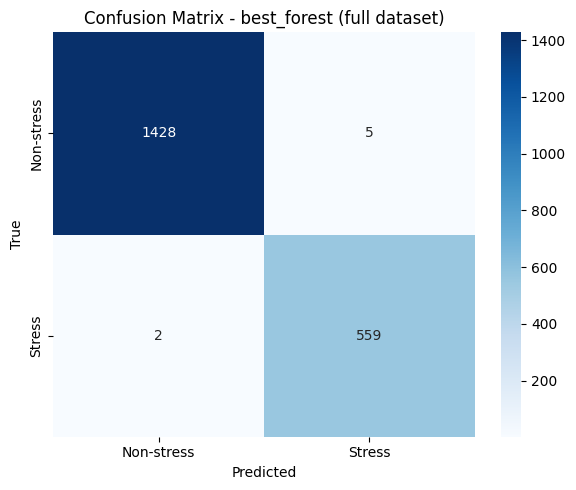

In [167]:
# Test best_forest on the full prepared dataset
y_pred_all = best_forest.predict(X)

print("Accuracy on full dataset:", accuracy_score(y, y_pred_all))
print(classification_report(y, y_pred_all))

cm = confusion_matrix(y, y_pred_all)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-stress", "Stress"],
    yticklabels=["Non-stress", "Stress"],
)
plt.title("Confusion Matrix - best_forest (full dataset)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

We try with unkown ECG

# Disease detection

Load the dataset

In [168]:
mitbih_train = pd.read_csv('dataset/mitbih/mitbih_train.csv', header=None)
mitbih_test = pd.read_csv('dataset/mitbih/mitbih_test.csv', header=None)
ptbdb_abnormal = pd.read_csv('dataset/mitbih/ptbdb_abnormal.csv', header=None)
ptbdb_normal = pd.read_csv('dataset/mitbih/ptbdb_normal.csv', header=None)

Data visualization

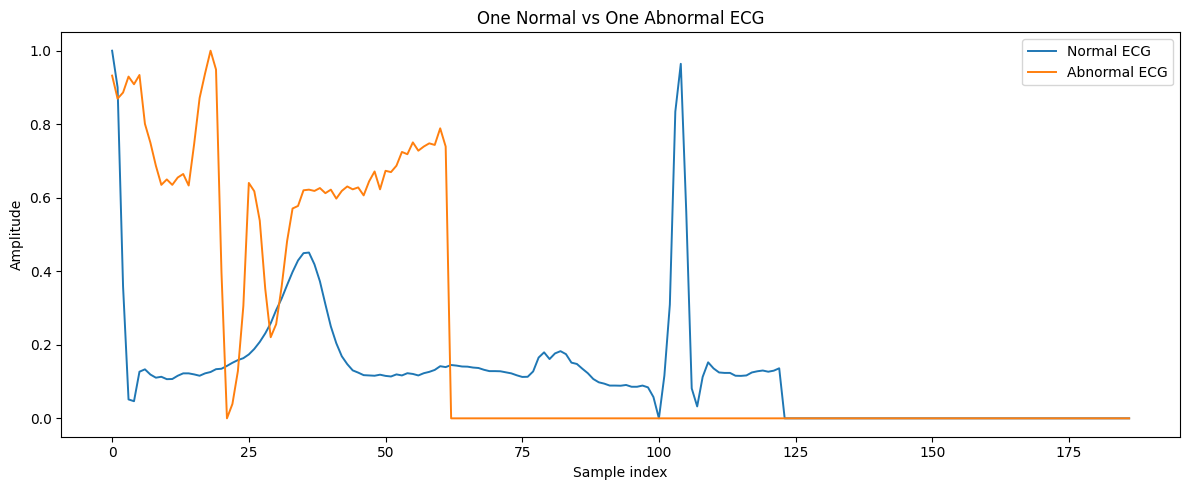

In [169]:
def extract_ecg_signal(row_values):
    if row_values.size > 1 and row_values[-1] in (0, 1):
        return row_values[:-1]
    return row_values

normal_signal = extract_ecg_signal(ptbdb_normal.iloc[0].to_numpy(dtype=float))
abnormal_signal = extract_ecg_signal(ptbdb_abnormal.iloc[0].to_numpy(dtype=float))

plt.figure(figsize=(12, 5))
plt.plot(normal_signal, label="Normal ECG", linewidth=1.4)
plt.plot(abnormal_signal, label="Abnormal ECG", linewidth=1.4)
plt.title("One Normal vs One Abnormal ECG")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

In [170]:
def print_dataset_info(name, df, has_label=True):
    print(f"\n=== {name} ===")
    print(f"Shape: {df.shape}")
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB")

    missing_total = int(df.isna().sum().sum())
    print(f"Missing values (total): {missing_total}")

    if has_label:
        label_col = df.columns[-1]
        label_counts = df[label_col].value_counts().sort_index()
        print("Label distribution:")
        print(label_counts)
        print("Label distribution (%):")
        print((label_counts / len(df) * 100).round(2))

    print("First rows:")
    print(df.head(3))


print_dataset_info("MITBIH Train", mitbih_train, has_label=True)
print_dataset_info("MITBIH Test", mitbih_test, has_label=True)
print_dataset_info("PTBDB Abnormal", ptbdb_abnormal, has_label=True)
print_dataset_info("PTBDB Normal", ptbdb_normal, has_label=True)

ptbdb_all = pd.concat([ptbdb_normal, ptbdb_abnormal], ignore_index=True)
label_col = ptbdb_all.columns[-1]
print("\n=== PTBDB Combined (Normal + Abnormal) ===")
print(f"Shape: {ptbdb_all.shape}")
print("Label distribution:")
print(ptbdb_all[label_col].value_counts().sort_index())


=== MITBIH Train ===
Shape: (87554, 188)
Memory usage: 125.58 MB
Missing values (total): 0
Label distribution:
187
0.0    72471
1.0     2223
2.0     5788
3.0      641
4.0     6431
Name: count, dtype: int64
Label distribution (%):
187
0.0    82.77
1.0     2.54
2.0     6.61
3.0     0.73
4.0     7.35
Name: count, dtype: float64
First rows:
        0         1         2         3         4         5         6    \
0  0.977941  0.926471  0.681373  0.245098  0.154412  0.191176  0.151961   
1  0.960114  0.863248  0.461538  0.196581  0.094017  0.125356  0.099715   
2  1.000000  0.659459  0.186486  0.070270  0.070270  0.059459  0.056757   

        7         8         9    ...  178  179  180  181  182  183  184  185  \
0  0.085784  0.058824  0.049020  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.088319  0.074074  0.082621  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.043243  0.054054  0.045946  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   186  187  
0  0.0  0.0  
1  0.0  0.

Physionet's MIT-BIH Arrhythmia Dataset
Classes: ['N': 0, 'S': 1, 'V': 2, 'F': 3, 'Q': 4]
N: Non-Ectopic Beats
S: Superventrical Ectopic Beats
V: Ventricular Ectopic Beats
F: Fusion Beats
Q: Unknown Beats

The PTB Diagnostic ECG Database
Classes : Normal, Abnormal

We'll merge the abnormal classes of the first dataset in one.

In [171]:
mitbih_all = pd.concat([mitbih_train, mitbih_test], ignore_index=True)

mitbih_normal = mitbih_all[mitbih_all[187] == 0].reset_index(drop=True)
mitbih_abnormal = mitbih_all[mitbih_all[187] != 0].reset_index(drop=True)

normal_merged = pd.concat([mitbih_normal, ptbdb_normal], ignore_index=True)
abnormal_merged = pd.concat([mitbih_abnormal, ptbdb_abnormal], ignore_index=True)

print("MITBIH all (train + test)")
print("shape:", mitbih_all.shape)
print("missing:", int(mitbih_all.isna().sum().sum()))
print("label 0:", int((mitbih_all[187] == 0).sum()))
print("label others:", int((mitbih_all[187] != 0).sum()))
print()

print("MITBIH normal (label 0)")
print("shape:", mitbih_normal.shape)
print("missing:", int(mitbih_normal.isna().sum().sum()))
print("label 0:", int((mitbih_normal[187] == 0).sum()))
print("label others:", int((mitbih_normal[187] != 0).sum()))
print()

print("MITBIH abnormal (label != 0)")
print("shape:", mitbih_abnormal.shape)
print("missing:", int(mitbih_abnormal.isna().sum().sum()))
print("label 0:", int((mitbih_abnormal[187] == 0).sum()))
print("label others:", int((mitbih_abnormal[187] != 0).sum()))
print()

print("Normal merged (MITBIH + PTBDB)")
print("shape:", normal_merged.shape)
print("missing:", int(normal_merged.isna().sum().sum()))
print("label 0:", int((normal_merged[187] == 0).sum()))
print("label others:", int((normal_merged[187] != 0).sum()))
print()

print("Abnormal merged (MITBIH + PTBDB)")
print("shape:", abnormal_merged.shape)
print("missing:", int(abnormal_merged.isna().sum().sum()))
print("label 0:", int((abnormal_merged[187] == 0).sum()))
print("label others:", int((abnormal_merged[187] != 0).sum()))

MITBIH all (train + test)
shape: (109446, 188)
missing: 0
label 0: 90589
label others: 18857

MITBIH normal (label 0)
shape: (90589, 188)
missing: 0
label 0: 90589
label others: 0

MITBIH abnormal (label != 0)
shape: (18857, 188)
missing: 0
label 0: 0
label others: 18857

Normal merged (MITBIH + PTBDB)
shape: (94635, 188)
missing: 0
label 0: 94635
label others: 0

Abnormal merged (MITBIH + PTBDB)
shape: (29363, 188)
missing: 0
label 0: 0
label others: 29363


Feature engineering

In [ ]:
# Windowed RR + HRV on merged datasets (simple)
sampling_rate_mitbih = 125
window_size = 30
step_size = window_size

def get_rr_ms(df, label_col=187, fs=125):
    all_rr = []
    all_peaks = []
    all_signals = []
    ecg_matrix = df.drop(columns=[label_col]).to_numpy(dtype=float)

    for row in ecg_matrix:
        peaks, _ = scipy.signal.find_peaks(row, distance=int(0.3 * fs))
        if len(peaks) > 1:
            rr = np.diff(peaks) * 1000 / fs
            all_rr.append(rr)
            all_peaks.append(peaks)
            all_signals.append(row)

    rr_ms = np.concatenate(all_rr) if all_rr else np.array([])
    # Signal et peaks concaténés pour les features morphologiques
    ecg_signal = np.concatenate(all_signals) if all_signals else np.array([])
    peaks_concat = np.concatenate(all_peaks) if all_peaks else np.array([], dtype=int)

    return ecg_signal, peaks_concat, rr_ms

 
def compute_morphological_features(beats):
    """
    beats: array 2D (n_beats, n_samples) — chaque ligne est un battement.
    """
    features_list = []

    for beat in beats:
        if len(beat) < 2:
            continue
        diff_beat = np.diff(beat)
        features_list.append({
            "beat_amplitude" : np.max(beat) - np.min(beat),
            "beat_mean"      : np.mean(beat),
            "beat_std"       : np.std(beat),
            "beat_skew"      : float(pd.Series(beat).skew()),
            "beat_kurt"      : float(pd.Series(beat).kurt()),
            "beat_energy"    : np.sum(beat ** 2),
            "qrs_slope"      : np.max(diff_beat),
        })

    if not features_list:
        return {}

    df_beats = pd.DataFrame(features_list)
    return {
        "mean_amplitude" : df_beats["beat_amplitude"].mean(),
        "std_amplitude"  : df_beats["beat_amplitude"].std(),
        "mean_energy"    : df_beats["beat_energy"].mean(),
        "std_energy"     : df_beats["beat_energy"].std(),
        "mean_qrs_slope" : df_beats["qrs_slope"].mean(),
        "mean_beat_std"  : df_beats["beat_std"].mean(),
        "mean_beat_skew" : df_beats["beat_skew"].mean(),
        "mean_beat_kurt" : df_beats["beat_kurt"].mean(),
    }

def hrv_windows(ecg_signal, peaks, rr_ms, dataset_name, target_label, win=30, step=30, fs=125):
    rows = []
    if len(rr_ms) < win:
        return pd.DataFrame()

    for start_idx in range(0, len(rr_ms) - win + 1, step):
        end_idx   = start_idx + win
        rr_window = rr_ms[start_idx:end_idx]
        pk_window = peaks[start_idx:end_idx]

        hrv_feats  = compute_hrv_features(rr_window)
        half_win = int(0.15 * fs)
        beats = [
            ecg_signal[max(0, p - half_win) : min(len(ecg_signal), p + half_win)]
            for p in pk_window
            if min(len(ecg_signal), p + half_win) - max(0, p - half_win) > 1
        ]
        morph_feats = compute_morphological_features(beats)

        row = {**hrv_feats, **morph_feats,
               "label": target_label, "dataset": dataset_name,
               "start_idx": start_idx, "end_idx": end_idx}
        rows.append(row)

    return pd.DataFrame(rows)


normal_ecg, normal_peaks, normal_rr_ms = get_rr_ms(normal_merged, fs=sampling_rate_mitbih)
abnormal_ecg, abnormal_peaks, abnormal_rr_ms = get_rr_ms(abnormal_merged, fs=sampling_rate_mitbih)

normal_windowed_hrv = hrv_windows(normal_ecg, normal_peaks, normal_rr_ms, "normal_merged", 0, win=window_size, step=step_size, fs=sampling_rate_mitbih)
abnormal_windowed_hrv = hrv_windows(abnormal_ecg, abnormal_peaks, abnormal_rr_ms, "abnormal_merged", 1, win=window_size, step=step_size, fs=sampling_rate_mitbih)

print("normal RR count:", len(normal_rr_ms))
print("abnormal RR count:", len(abnormal_rr_ms))
print("normal windows:", len(normal_windowed_hrv))
print("abnormal windows:", len(abnormal_windowed_hrv))
print(normal_windowed_hrv.head())
print(abnormal_windowed_hrv.head())

normal RR count: 94634
abnormal RR count: 29362
normal windows: 3154
abnormal windows: 978
       RR_mean  RR_min  RR_max  RR_range  RR_diff_max  RR_diff_std  \
0  1473.866667   168.0  2592.0    2424.0       2088.0  1159.677613   
1  1504.800000   456.0  2536.0    2080.0       2080.0   928.363535   
2  1487.200000   488.0  2504.0    2016.0       2016.0  1009.978090   
3  1515.466667   432.0  2576.0    2144.0       2144.0   992.906494   
4  1486.400000   600.0  2272.0    1672.0       1648.0   698.579391   

         SDNN        RMSSD      pNN50     LF/HF  ...  mean_energy  std_energy  \
0  643.877200  1160.963215  89.655172  0.046420  ...     3.779939    1.671159   
1  553.876424   930.983314  72.413793  0.049841  ...     3.625757    2.009697   
2  570.919632  1010.303881  82.758621  0.142203  ...     5.092701    5.297225   
3  558.343009   992.925041  86.206897  0.219787  ...     5.067301    4.847586   
4  417.282127   698.628410  68.965517  0.220173  ...     4.276611    4.970716   

 

We'll normalize the data later

In [183]:
from sklearn.preprocessing import StandardScaler

We'll train Isolation Forest

df_train shape: (2523, 29)
df_test shape: (731, 29)
Accuracy:  0.7702
Precision (reflects the reliability of the detected anomalies): 0.1909
Recall (ability of the model to correctly detect anomalies,):    0.2100


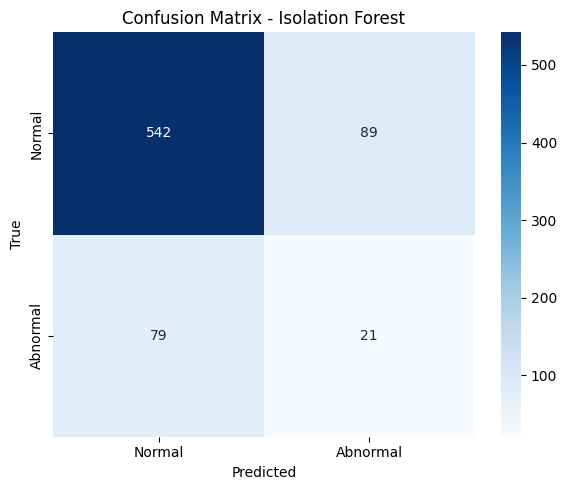

In [184]:
normal_df = normal_windowed_hrv.copy().reset_index(drop=True)
abnormal_df = abnormal_windowed_hrv.copy().reset_index(drop=True)

train_frac = 0.8
random_state = 42

normal_train_df = normal_windowed_hrv.sample(frac=train_frac, random_state=random_state)
normal_test_df = normal_windowed_hrv.drop(index=normal_train_df.index)

normal_train_df = normal_train_df.reset_index(drop=True)
normal_test_df = normal_test_df.reset_index(drop=True)

# Sample exactly 200 anomalies for test set
abnormal_test_df = abnormal_df.sample(n=min(100, len(abnormal_df)), random_state=random_state)

test_df = pd.concat([normal_test_df, abnormal_test_df], ignore_index=True)

df_train = normal_train_df.copy()
df_test = test_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

feature_cols = ["RR_mean", "SDNN", "RMSSD", "pNN50", "LF/HF"]
X_train_if = df_train[feature_cols]
X_test_if = df_test[feature_cols]
y_test_if = df_test["label"].astype(int)

#Standardize features for Isolation Forest
scaler = StandardScaler()
X_train_if_scaled = scaler.fit_transform(X_train_if)
X_test_if_scaled = scaler.transform(X_test_if)

iso_forest = IsolationForest(n_estimators=500,
                             contamination=0.1, 
                             random_state=random_state,
                             max_features = 5,
                             )
iso_forest.fit(X_train_if_scaled)
scores = iso_forest.decision_function(X_test_if_scaled)
threshold = np.percentile(scores, 15)


# IsolationForest: 1=inlier(normal), -1=outlier(anomaly)
# y_pred_raw = iso_forest.predict(X_test_if_scaled)
# y_pred_if = (y_pred_raw == -1).astype(int)
y_pred_if = (scores < threshold).astype(int)


print("df_train shape:", df_train.shape)
print("df_test shape:", df_test.shape)

# Calculate metrics
from sklearn.metrics import precision_score, recall_score
accuracy = accuracy_score(y_test_if, y_pred_if)
precision = precision_score(y_test_if, y_pred_if)
recall = recall_score(y_test_if, y_pred_if)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision (reflects the reliability of the detected anomalies): {precision:.4f}")
print(f"Recall (ability of the model to correctly detect anomalies,):    {recall:.4f}")
cm_if = confusion_matrix(y_test_if, y_pred_if)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_if,
    annot=True,
    fmt="d", 
    cmap="Blues",
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"],
)
plt.title("Confusion Matrix - Isolation Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

We struggle to find a balance between recall and precision

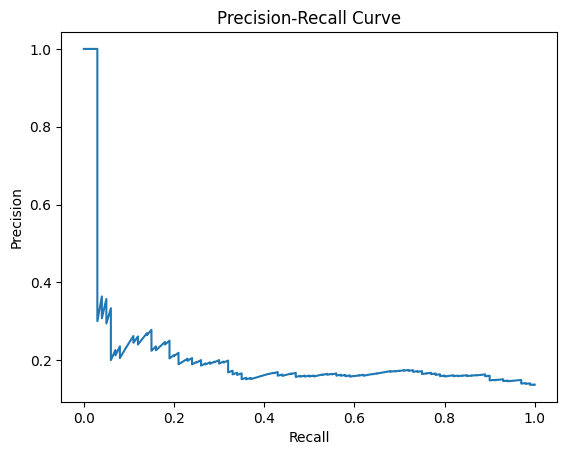

In [185]:
from sklearn.metrics import precision_recall_curve

# Compute precision-recall values
precision, recall, thresholds = precision_recall_curve(y_test_if, -scores)

# Plot
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

The model can't detect anomalies, it can be because the features are not very distinctive

Let's see what appen if we add features (RR_min, RR_max, RR_range, RR_diff_std, RR_diff_max)

In [186]:
from scipy.stats import skew, kurtosis

In [187]:
def compute_hrv_features(rr_intervals_ms):
    """
    Compute HRV features from RR intervals in milliseconds.
    
    Parameters:
    - rr_intervals_ms: numpy array of RR intervals in ms
    
    Returns:
    - dict with SDNN, RMSSD, pNN50, LF/HF ratio
    """
    rr_ms = np.array(rr_intervals_ms)
    
    rr_mean = np.mean(rr_ms)
    
    rr_min = np.min(rr_ms)
    
    rr_max = np.max(rr_ms)
    
    rr_range = rr_max - rr_min
    
    rr_diff = np.diff(rr_ms)
    
    rr_diff_max = np.max(np.abs(rr_diff))
    
    rr_diff_std = np.std(rr_diff) 
    
    #rr_skewness = skew(rr_ms)
    
    #rr_kurtosis = kurtosis(rr_ms)
    
    sdnn = np.std(rr_ms)
    
    diff_rr = np.diff(rr_ms)
    rmssd = np.sqrt(np.mean(diff_rr ** 2))
    
    pnn50 = 100 * np.sum(np.abs(diff_rr) > 50) / len(diff_rr)
    
    fft_result = np.fft.fft(rr_ms)
    freqs = np.fft.fftfreq(len(rr_ms), d=np.mean(rr_ms) / 1000)
    power = np.abs(fft_result) ** 2
    
    lf_mask = (freqs >= 0.04) & (freqs <= 0.15)
    hf_mask = (freqs >= 0.15) & (freqs <= 0.40)
    
    lf_power = np.sum(power[lf_mask])
    hf_power = np.sum(power[hf_mask])
    
    lf_hf_ratio = lf_power / hf_power if hf_power > 0 else 0

    #nouvelles variables
    vlf_mask = (freqs >= 0.003) & (freqs < 0.04)
    vlf_power = np.sum(power[vlf_mask])
    
    return {
        "RR_mean": rr_mean,
        "RR_min": rr_min,
        "RR_max": rr_max,
        "RR_range": rr_range,
        "RR_diff_max": rr_diff_max,
        "RR_diff_std": rr_diff_std,
        #"skewness": rr_skewness,
        #"kurtosis": rr_kurtosis,
        "SDNN": sdnn,
        "RMSSD": rmssd,
        "pNN50": pnn50,
        "LF/HF": lf_hf_ratio,
        # --- nouvelles features ---
        "VLF_power"   : vlf_power,
        "LF_power"    : lf_power,
        "HF_power"    : hf_power,
        "skewness"    : float(pd.Series(rr_ms).skew()),     # asymétrie distribution RR
        "kurtosis"    : float(pd.Series(rr_ms).kurt()),     # aplatissement distribution RR
        "CV"          : np.std(rr_ms) / np.mean(rr_ms),    # coefficient de variation
        "pNN20"       : 100 * np.sum(np.abs(diff_rr) > 20) / len(diff_rr),
    }




normal_ecg, normal_peaks, normal_rr_ms = get_rr_ms(normal_merged, fs=sampling_rate_mitbih)
abnormal_ecg, abnormal_peaks, abnormal_rr_ms = get_rr_ms(abnormal_merged, fs=sampling_rate_mitbih)

normal_windowed_hrv = hrv_windows(normal_ecg, normal_peaks, normal_rr_ms, "normal_merged", 0, win=window_size, step=step_size, fs=sampling_rate_mitbih)
abnormal_windowed_hrv = hrv_windows(abnormal_ecg, abnormal_peaks, abnormal_rr_ms, "abnormal_merged", 1, win=window_size, step=step_size, fs=sampling_rate_mitbih)

normal_df = normal_windowed_hrv.copy().reset_index(drop=True)
abnormal_df = abnormal_windowed_hrv.copy().reset_index(drop=True)

train_frac = 0.8
random_state = 42

normal_train_df = normal_windowed_hrv.sample(frac=train_frac, random_state=random_state)
normal_test_df = normal_windowed_hrv.drop(index=normal_train_df.index)

normal_train_df = normal_train_df.reset_index(drop=True)
normal_test_df = normal_test_df.reset_index(drop=True)

# Sample exactly 200 anomalies for test set
abnormal_test_df = abnormal_df.sample(n=min(100, len(abnormal_df)), random_state=random_state)

test_df = pd.concat([normal_test_df, abnormal_test_df], ignore_index=True)

df_train = normal_train_df.copy()
df_test = test_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

feature_cols = ["RR_mean", "SDNN", "RMSSD", "pNN50", "LF/HF","RR_max","RR_min","RR_range","RR_diff_max","RR_diff_std", "VLF_power", "LF_power", "HF_power",
                "skewness", "kurtosis", "CV", "pNN20"]
X_train_if = df_train[feature_cols]
X_test_if = df_test[feature_cols]
y_test_if = df_test["label"].astype(int)

#Standardize features for Isolation Forest
scaler = StandardScaler()
X_train_if_scaled = scaler.fit_transform(X_train_if)
X_test_if_scaled = scaler.transform(X_test_if)

df_train shape: (2523, 29)
df_test shape: (731, 29)
Accuracy:  0.7866
Precision (reflects the reliability of the detected anomalies): 0.2455
Recall (ability of the model to correctly detect anomalies,):    0.2700


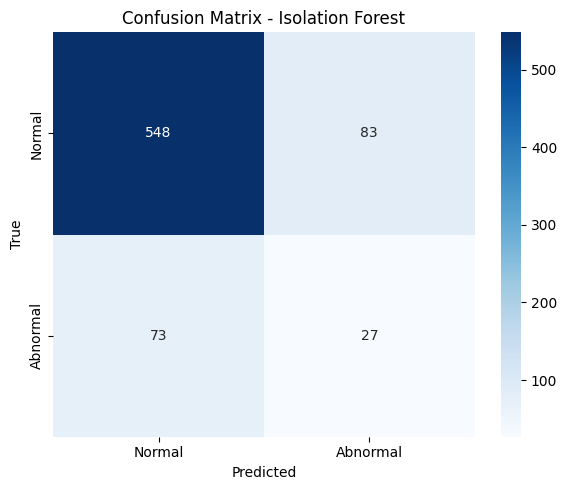

In [188]:
iso_forest = IsolationForest(n_estimators=500,
                             contamination=0.1, 
                             random_state=random_state,
                             max_features = 5,
                             )
iso_forest.fit(X_train_if_scaled)
scores = iso_forest.decision_function(X_test_if_scaled)
threshold = np.percentile(scores, 15)


# IsolationForest: 1=inlier(normal), -1=outlier(anomaly)
# y_pred_raw = iso_forest.predict(X_test_if_scaled)
# y_pred_if = (y_pred_raw == -1).astype(int)
y_pred_if = (scores < threshold).astype(int)


print("df_train shape:", df_train.shape)
print("df_test shape:", df_test.shape)

# Calculate metrics
from sklearn.metrics import precision_score, recall_score
accuracy = accuracy_score(y_test_if, y_pred_if)
precision = precision_score(y_test_if, y_pred_if)
recall = recall_score(y_test_if, y_pred_if)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision (reflects the reliability of the detected anomalies): {precision:.4f}")
print(f"Recall (ability of the model to correctly detect anomalies,):    {recall:.4f}")
cm_if = confusion_matrix(y_test_if, y_pred_if)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_if,
    annot=True,
    fmt="d", 
    cmap="Blues",
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"],
)
plt.title("Confusion Matrix - Isolation Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

We'll try to reduce the windows size

df_train shape: (5046, 29)
df_test shape: (1362, 29)
Accuracy:  0.7893
Precision (reflects the reliability of the detected anomalies): 0.1575
Recall (ability of the model to correctly detect anomalies,):    0.4300


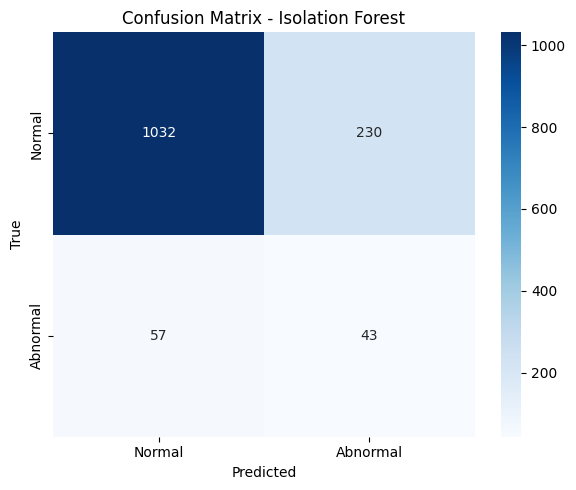

In [189]:
sampling_rate_mitbih = 125
window_size = 15
step_size = window_size

normal_ecg, normal_peaks, normal_rr_ms = get_rr_ms(normal_merged, fs=sampling_rate_mitbih)
abnormal_ecg, abnormal_peaks, abnormal_rr_ms = get_rr_ms(abnormal_merged, fs=sampling_rate_mitbih)

normal_windowed_hrv = hrv_windows(normal_ecg, normal_peaks, normal_rr_ms, "normal_merged", 0, win=window_size, step=step_size, fs=sampling_rate_mitbih)
abnormal_windowed_hrv = hrv_windows(abnormal_ecg, abnormal_peaks, abnormal_rr_ms, "abnormal_merged", 1, win=window_size, step=step_size, fs=sampling_rate_mitbih)

normal_df = normal_windowed_hrv.copy().reset_index(drop=True)
abnormal_df = abnormal_windowed_hrv.copy().reset_index(drop=True)

train_frac = 0.8
random_state = 42

normal_train_df = normal_windowed_hrv.sample(frac=train_frac, random_state=random_state)
normal_test_df = normal_windowed_hrv.drop(index=normal_train_df.index)

normal_train_df = normal_train_df.reset_index(drop=True)
normal_test_df = normal_test_df.reset_index(drop=True)

# Sample exactly 200 anomalies for test set
abnormal_test_df = abnormal_df.sample(n=min(100, len(abnormal_df)), random_state=random_state)

test_df = pd.concat([normal_test_df, abnormal_test_df], ignore_index=True)

df_train = normal_train_df.copy()
df_test = test_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

feature_cols = ["RR_mean", "SDNN", "RMSSD", "pNN50", "LF/HF",
                "RR_max", "RR_min", "RR_range", "RR_diff_max", "RR_diff_std",
                "VLF_power", "LF_power", "HF_power",
                "skewness", "kurtosis", "CV", "pNN20",
                "mean_amplitude", "std_amplitude", "mean_energy",
                "std_energy", "mean_qrs_slope", "mean_beat_std",
                "mean_beat_skew", "mean_beat_kurt"]
X_train_if = df_train[feature_cols]
X_test_if = df_test[feature_cols]
y_test_if = df_test["label"].astype(int)

#Standardize features for Isolation Forest
scaler = StandardScaler()
X_train_if_scaled = scaler.fit_transform(X_train_if)
X_test_if_scaled = scaler.transform(X_test_if)

iso_forest = IsolationForest(n_estimators=500,
                             contamination=0.15, 
                             random_state=random_state,
                             max_features = 10,
                             )
iso_forest.fit(X_train_if_scaled)
scores = iso_forest.decision_function(X_test_if_scaled)
threshold = np.percentile(scores, 20)


# IsolationForest: 1=inlier(normal), -1=outlier(anomaly)
# y_pred_raw = iso_forest.predict(X_test_if_scaled)
# y_pred_if = (y_pred_raw == -1).astype(int)
y_pred_if = (scores < threshold).astype(int)


print("df_train shape:", df_train.shape)
print("df_test shape:", df_test.shape)

# Calculate metrics
from sklearn.metrics import precision_score, recall_score
accuracy = accuracy_score(y_test_if, y_pred_if)
precision = precision_score(y_test_if, y_pred_if)
recall = recall_score(y_test_if, y_pred_if)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision (reflects the reliability of the detected anomalies): {precision:.4f}")
print(f"Recall (ability of the model to correctly detect anomalies,):    {recall:.4f}")
cm_if = confusion_matrix(y_test_if, y_pred_if)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_if,
    annot=True,
    fmt="d", 
    cmap="Blues",
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"],
)
plt.title("Confusion Matrix - Isolation Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()




j'arrive pas jv péter un plomb

Try to create frequency feature

Maybe the data has a lot of noise so it's difficuolt for the forest to know what is really abnormal or just noise

We try Random Forest 

Accuracy:  0.8046
Precision: 0.6700
Recall:    0.3427


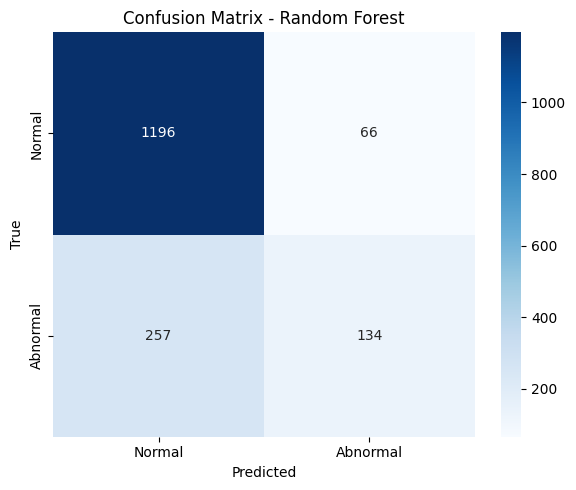


Feature importances:
RR_max         0.117472
RR_min         0.114155
RR_diff_max    0.111498
RR_range       0.110445
SDNN           0.107373
LF/HF          0.103294
RR_mean        0.102883
RR_diff_std    0.091063
RMSSD          0.090709
pNN50          0.051108
dtype: float64


In [190]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Recombiner normal + abnormal pour le supervisé ---
normal_df["label"] = 0
abnormal_df["label"] = 1

full_df = pd.concat([normal_df, abnormal_df], ignore_index=True).dropna()

feature_cols = ["RR_mean", "SDNN", "RMSSD", "pNN50", "LF/HF",
                "RR_max", "RR_min", "RR_range", "RR_diff_max", "RR_diff_std"]

X = full_df[feature_cols]
y = full_df["label"]

# --- 2. Split train/test stratifié ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# --- 3. Standardisation ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# --- 4. Random Forest ---
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)

# --- 5. Métriques ---
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Abnormal"],
            yticklabels=["Normal", "Abnormal"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# --- 6. Feature importance (bonus) ---
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importances:")
print(importances)

We try to do One-Class Support Vector Machines

Accuracy:  0.8363
Precision: 0.0872
Recall:    0.1300


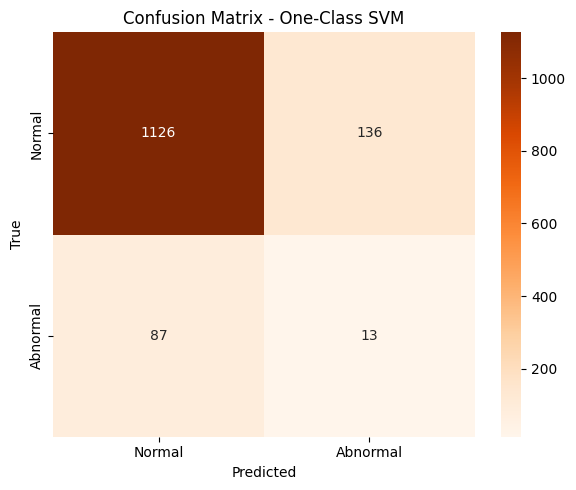

In [191]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Préparer les données ---
# Entraînement : uniquement les normaux
# Test : normaux + anormaux (comme tu faisais avec l'Isolation Forest)

feature_cols = ["RR_mean", "SDNN", "RMSSD", "pNN50", "LF/HF",
                "RR_max", "RR_min", "RR_range", "RR_diff_max", "RR_diff_std"]

X_train_oc = df_train[feature_cols]   # seulement les normaux

X_test_oc  = df_test[feature_cols]    # normaux + anormaux
y_test_oc  = df_test["label"].astype(int)

# --- 2. Standardisation ---
scaler = StandardScaler()
X_train_oc_scaled = scaler.fit_transform(X_train_oc)
X_test_oc_scaled  = scaler.transform(X_test_oc)

# --- 3. One-Class SVM ---
# nu ≈ proportion attendue d'anomalies (entre 0.05 et 0.2 à tester)
oc_svm = OneClassSVM(kernel='rbf', nu=0.1, gamma='scale')
oc_svm.fit(X_train_oc_scaled)

# --- 4. Prédiction ---
# One-Class SVM retourne : +1 = normal (inlier), -1 = anomalie (outlier)
y_pred_raw = oc_svm.predict(X_test_oc_scaled)
y_pred_oc  = (y_pred_raw == -1).astype(int)   # -1 → 1 (anomalie), +1 → 0 (normal)

# --- 5. Métriques ---
print(f"Accuracy:  {accuracy_score(y_test_oc, y_pred_oc):.4f}")
print(f"Precision: {precision_score(y_test_oc, y_pred_oc):.4f}")
print(f"Recall:    {recall_score(y_test_oc, y_pred_oc):.4f}")

cm = confusion_matrix(y_test_oc, y_pred_oc)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Normal", "Abnormal"],
            yticklabels=["Normal", "Abnormal"])
plt.title("Confusion Matrix - One-Class SVM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()